# Headers

In [2]:
import sys
sys.path.append('/content/drive/MyDrive/universidad/vision_por_computador/clases/Import_general')
print(sys.path)

['/content', '/env/python', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/universidad/vision_por_computador/clases/Import_general']


In [3]:
!ls /content/drive/MyDrive/universidad/vision_por_computador/clases/Import_general

Detection  ejemplo_yolo.ipynb  __pycache__  utiles.py


In [4]:
!rm -rf /content/drive/MyDrive/universidad/vision_por_computador/clases/Import_general/__pycache__

In [5]:
import importlib.util

ruta_modulo = "/content/drive/MyDrive/universidad/vision_por_computador/clases/Import_general/utiles.py"
spec = importlib.util.spec_from_file_location("utiles", ruta_modulo)
utiles = importlib.util.module_from_spec(spec)
spec.loader.exec_module(utiles)

print("Módulo importado correctamente ✅")

Módulo importado correctamente ✅


In [6]:
from    utiles import *
import  cv2
import  numpy as np
import  matplotlib.pyplot as plt


# Cargando imagen

array([[[174, 181, 191],
        [174, 181, 191],
        [174, 181, 191],
        ...,
        [174, 181, 191],
        [174, 181, 191],
        [174, 181, 191]],

       [[174, 181, 191],
        [174, 181, 191],
        [174, 181, 191],
        ...,
        [174, 181, 191],
        [174, 181, 191],
        [174, 181, 191]],

       [[174, 181, 191],
        [174, 181, 191],
        [174, 181, 191],
        ...,
        [174, 181, 191],
        [174, 181, 191],
        [174, 181, 191]],

       ...,

       [[151, 148, 143],
        [151, 148, 143],
        [151, 148, 143],
        ...,
        [ 69,  36,   3],
        [ 65,  34,   3],
        [ 63,  32,   1]],

       [[151, 148, 143],
        [151, 148, 143],
        [151, 148, 143],
        ...,
        [ 67,  36,   5],
        [ 67,  36,   5],
        [ 67,  36,   7]],

       [[151, 148, 143],
        [151, 148, 143],
        [151, 148, 143],
        ...,
        [ 67,  36,   5],
        [ 68,  37,   8],
        [ 68,  37,   8]]], dtype=uint8)
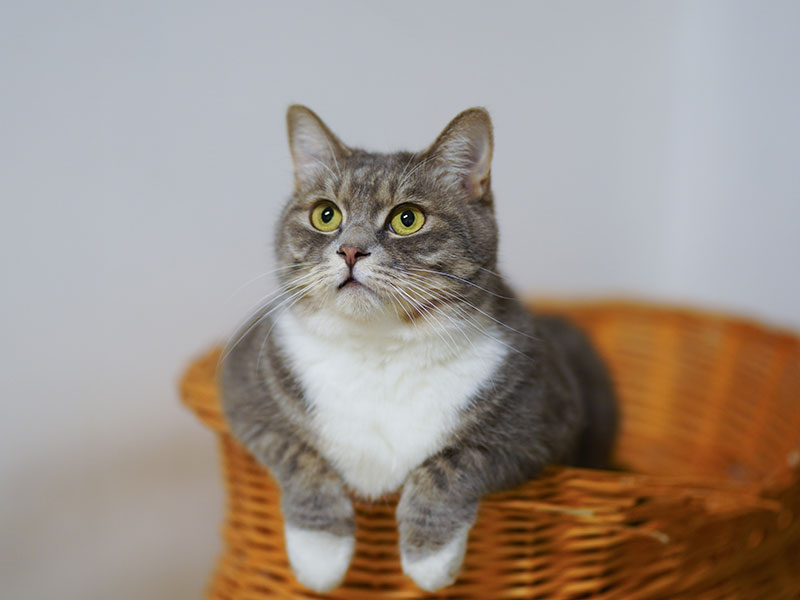

In [ ]:
url   = "https://www.clinicanimal.vet/wp-content/uploads/2022/10/gato-en-parque.jpg"
image = u_cargar_imagen(url, metodo="pillow")
image

# Filtrado espacial

array([[[174, 181, 191],
        [174, 181, 191],
        [174, 181, 191],
        ...,
        [174, 181, 191],
        [174, 181, 191],
        [174, 181, 191]],

       [[174, 181, 191],
        [174, 181, 191],
        [174, 181, 191],
        ...,
        [174, 181, 191],
        [174, 181, 191],
        [174, 181, 191]],

       [[174, 181, 191],
        [174, 181, 191],
        [174, 181, 191],
        ...,
        [174, 181, 191],
        [174, 181, 191],
        [174, 181, 191]],

       ...,

       [[151, 148, 143],
        [151, 148, 143],
        [151, 148, 143],
        ...,
        [ 69,  36,   3],
        [ 68,  35,   3],
        [ 68,  35,   3]],

       [[151, 148, 143],
        [151, 148, 143],
        [151, 148, 143],
        ...,
        [ 68,  36,   3],
        [ 68,  35,   3],
        [ 67,  35,   3]],

       [[151, 148, 143],
        [151, 148, 143],
        [151, 148, 143],
        ...,
        [ 68,  35,   3],
        [ 67,  35,   3],
        [ 67,  35,   3]]], dtype=uint8)
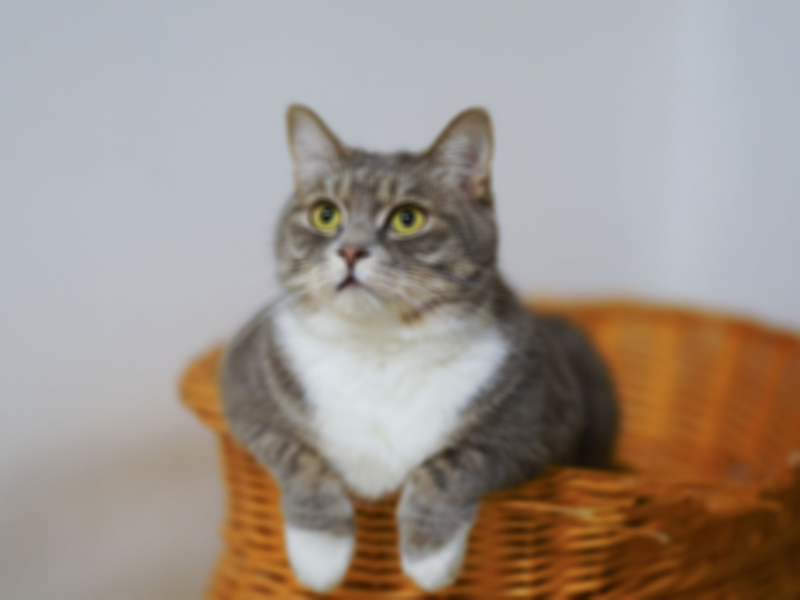

In [ ]:
kernel  = np.ones((6, 6), np.float32) / 49
img     = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
img

In [ ]:
def normalize_kernel(kernel):
    return kernel / np.sum(kernel) if np.sum(kernel) != 0 else kernel


In [ ]:
kernels = {
    "Media": np.ones((5, 5), np.float32) / 25,
    "Butterworth": normalize_kernel(np.array([[1, 4, 6, 4, 1],
                                                [4, 16, 24, 16, 4],
                                                [6, 24, 36, 24, 6],
                                                [4, 16, 24, 16, 4],
                                                [1, 4, 6, 4, 1]], dtype=np.float32)),
    "Gaussiano": cv2.getGaussianKernel(5, 1) @ cv2.getGaussianKernel(5, 1).T,
    "Laplaciano": np.array([[0, 1, 0, 1, 0],
                             [1, -4, 1, -4, 1],
                             [0, 1, 8, 1, 0],
                             [1, -4, 1, -4, 1],
                             [0, 1, 0, 1, 0]], dtype=np.float32),
    "Pasa Alta": np.array([[-1, -1, -1, -1, -1],
                             [-1, 2, 2, 2, -1],
                             [-1, 2, 8, 2, -1],
                             [-1, 2, 2, 2, -1],
                             [-1, -1, -1, -1, -1]], dtype=np.float32),
    "Pasa Baja": np.ones((5, 5), np.float32) / 25,
    "Pasa Media": np.array([[0, -1, 0, -1, 0],
                              [-1, 2, -1, 2, -1],
                              [0, -1, 8, -1, 0],
                              [-1, 2, -1, 2, -1],
                              [0, -1, 0, -1, 0]], dtype=np.float32)
}

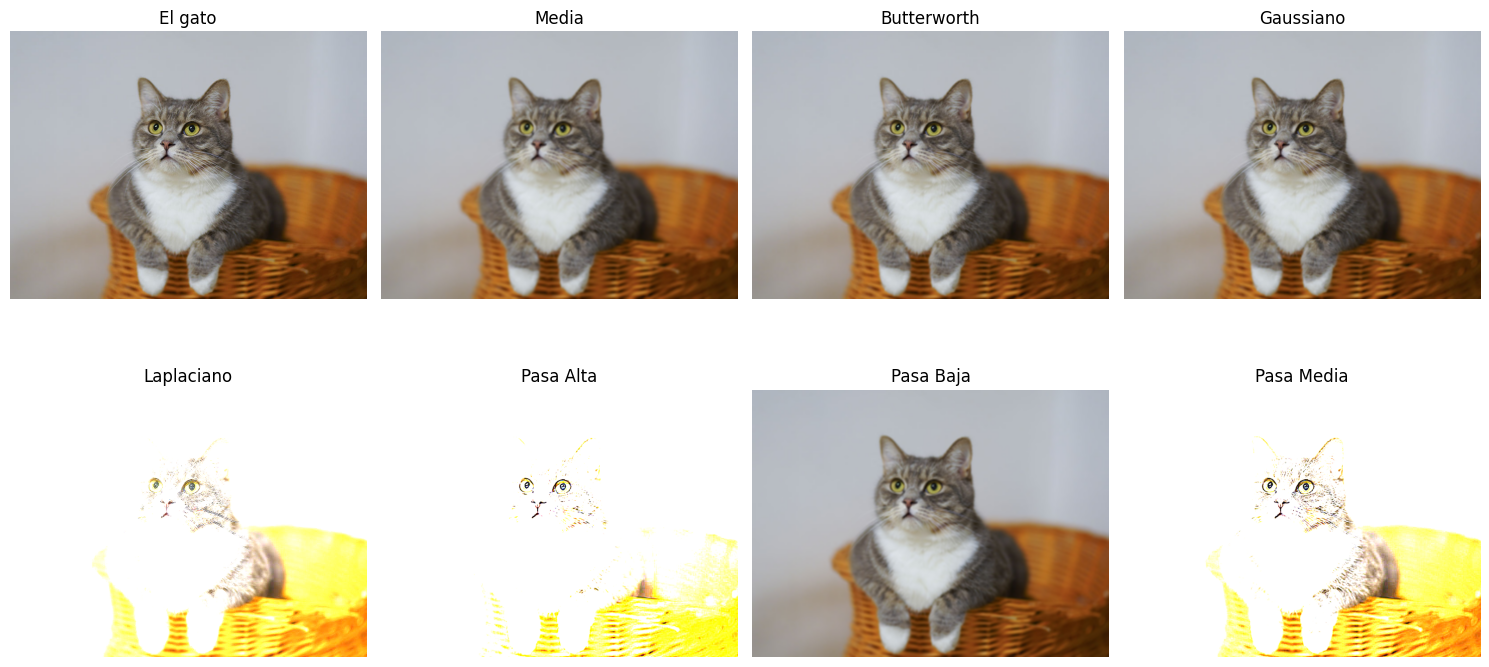

In [ ]:
filtered_images = {}
for name, kernel in kernels.items():
    filtered_images[name] = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

axes[0].imshow(image)
axes[0].set_title('El gato')
axes[0].axis("off")

for i, (name, img) in enumerate(filtered_images.items()):
    axes[i+1].imshow(img)
    axes[i+1].set_title(name)
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()


---
# Práctica [Participación en clase]

* Codifique cada uno de los filtros de manera manual muestre las imágenes.Y que adicionalmente muestre el filtro, para que se vea bien las matrices deben ser de $7\times7$ a mayor tamaño.
---



# Operarodes no Lineales
<p align="justify"> En el procesamiento de imágenes, los operadores no lineales son transformaciones que no cumplen con los principios de superposición y homogeneidad (es decir, la salida no es una combinación lineal de las entradas). Estos operadores suelen usarse para mejorar la calidad de la imagen, reducir ruido, detectar bordes y segmentar objetos. Algunos de los operadores no lineales más comunes incluyen:

# **Principios de Superposición y Homogeneidad**

En el procesamiento de imágenes, un operador es **lineal** si cumple con dos principios fundamentales: **superposición** y **homogeneidad**. Si un operador no cumple con alguno de estos principios, se considera **no lineal**.

## **1. Principio de Superposición (Aditividad)**

Este principio establece que la respuesta de un sistema lineal a la suma de dos entradas es igual a la suma de las respuestas individuales de cada entrada. Matemáticamente:

$$ T(f_1 + f_2) = T(f_1) + T(f_2) $$

Donde:
- $T$ representa el operador o transformación aplicada a la imagen.
- $f_1$  y $f_2$ son dos imágenes de entrada.
- $T(f_1)$ y $T(f_2)$ son las imágenes resultantes después de aplicar el operador.

### **Ejemplo en imágenes**
Si aplicamos un operador lineal a la suma de dos imágenes, el resultado debe ser igual a la suma de las imágenes procesadas por separado:

$$ T(f_1 + f_2) = T(f_1) + T(f_2) $$

Si este principio no se cumple, el operador es **no lineal**.



## **2. Principio de Homogeneidad (Escalabilidad)**

Este principio indica que si se escala la entrada por un factor constante, la salida también se escala por el mismo factor. Matemáticamente:

$$ T(a f) = a T(f) $$

Donde:
- $a$ es un número escalar (por ejemplo, un valor real o entero).
- $f$ es la imagen de entrada.
- $T(f)$ es la imagen resultante después de aplicar el operador.

### **Ejemplo en imágenes**
Si un filtro lineal se aplica a una imagen que ha sido multiplicada por un escalar $a$, el resultado debe ser igual a aplicar el filtro y luego multiplicar por $a$. Si esto no se cumple, el operador es **no lineal**.


## **Ejemplo de un Operador Lineal: Filtro Promedio**
El **filtro promedio** es un operador lineal porque cumple con ambos principios:
- La suma de dos imágenes filtradas con el filtro promedio es igual a la suma de las imágenes antes de filtrar y luego aplicar el filtro.
- Si multiplicamos la imagen por un escalar antes de aplicar el filtro, el resultado es igual a aplicar el filtro y luego multiplicar por el escalar.


## **Ejemplo de un Operador No Lineal: Filtro de Mediana**

El **filtro de mediana** es **no lineal** porque no cumple con los principios de superposición y homogeneidad:

- La mediana no es una operación aditiva, por lo que:

  $$ T(f_1 + f_2) \neq T(f_1) + T(f_2) $$

- La mediana no escala de manera proporcional, lo que significa que:

  $$ T(a f) \neq a T(f) $$

Esto implica que el filtro de mediana modifica la imagen de manera no lineal, lo que puede ser útil para eliminar ruido impulsivo sin afectar demasiado los bordes de la imagen.

---
# Práctica [Participación en clase]

* Implemente los filtros **mediana, moda y bilateral**, muestre los resultados en imágenes de salida.
---


## Operaciones morfológicas


In [ ]:
kernels = {
  "Prewitt X": np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]], dtype=np.float32),
  "Prewitt Y": np.array([[-1, -1, -1],
                            [ 0,  0,  0],
                            [ 1,  1,  1]], dtype=np.float32),
  "Sobel X": np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]], dtype=np.float32),
  "Sobel Y": np.array([[-1, -2, -1],
                            [ 0,  0,  0],
                            [ 1,  2,  1]], dtype=np.float32)
}

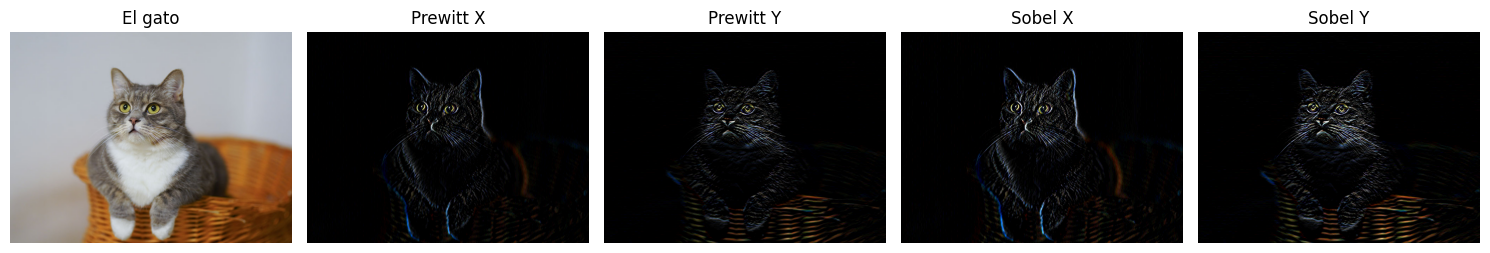

In [ ]:
filtered_images = {}
for name, kernel in kernels.items():
    filtered_images[name] = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)

fig, axes = plt.subplots(1, 5, figsize=(15, 8))
axes = axes.ravel()

axes[0].imshow(image)
axes[0].set_title('El gato')
axes[0].axis("off")

for i, (name, img) in enumerate(filtered_images.items()):
    axes[i+1].imshow(img)
    axes[i+1].set_title(name)
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

# Detector de Canny
El detector de bordes de Canny es un algoritmo que identifica contornos en imágenes mediante varios pasos clave. Primero, se aplica un filtro Gaussiano para suavizar la imagen y reducir el ruido. Luego, se calculan los gradientes de intensidad utilizando los filtros de Sobel en direcciones x e y. A continuación, se realiza la supresión no máxima, que delgada los bordes manteniendo solo los píxeles con máxima magnitud en la dirección del gradiente. Finalmente, se aplica un umbral con histéresis para eliminar bordes débiles y conectar los más fuertes, asegurando la detección de contornos bien definidos.

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
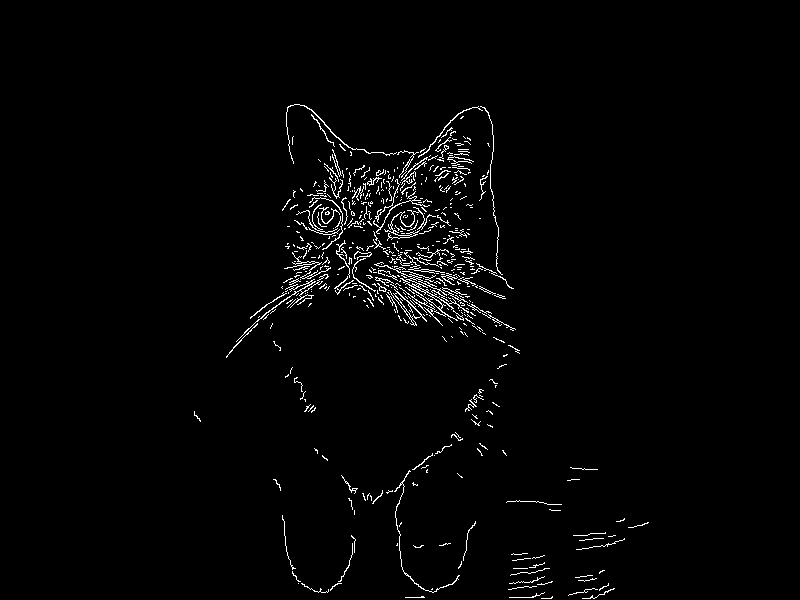

In [ ]:
can_img = cv2.Canny(image, 150,200 )
can_img

---
# Práctica [Participación en clase]

* Extraer los bordes utilizando substracción de imágenes.
---

# Operadores morfológicos

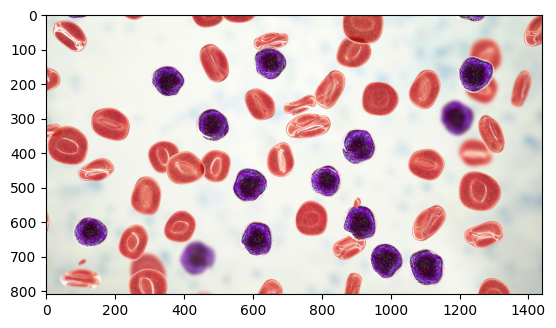

In [ ]:
url_cel = 'https://i0.wp.com/www.sciencenews.org/wp-content/uploads/2023/09/091823_DI_human-cell-census_cells_feat.jpg'
img     = u_cargar_imagen(url_cel, metodo="pillow")
plt.imshow(img)
plt.show()

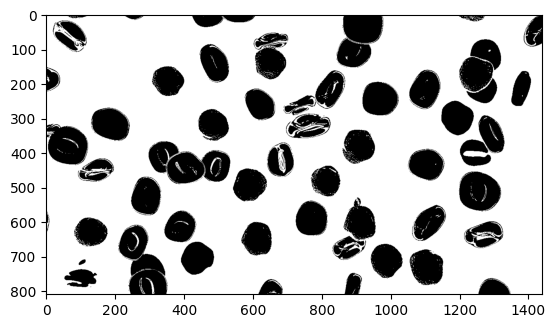

In [ ]:
gray_img              = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresholded_img  = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary_img            = thresholded_img / 255
plt.imshow(binary_img, cmap='gray')
plt.show()

<style>
    table { width: 100%; border-collapse: collapse; }
    th, td { border: 1px solid black; padding: 8px; text-align: justify; }
    th { background-color: #f2f2f2; }
</style>

### Resumen de Operaciones Morfológicas

<table>
    <tr>
        <th>Operación</th>
        <th>Descripción</th>
        <th>Funcionamiento</th>
    </tr>
    <tr>
        <td><b>Erosión</b></td>
        <td>Reduce el tamaño de los objetos en la imagen.</td>
        <td>Si algún píxel en la región cubierta por el kernel es negro (0), el píxel central se vuelve negro. Se usa para eliminar ruido y reducir detalles.</td>
    </tr>
    <tr>
        <td><b>Dilatación</b></td>
        <td>Expande el tamaño de los objetos en la imagen.</td>
        <td>Si al menos un píxel dentro del kernel es blanco (255), el píxel central se vuelve blanco. Se usa para cerrar pequeños huecos.</td>
    </tr>
    <tr>
        <td><b>Apertura</b></td>
        <td>Eliminación de ruido sin afectar la forma general.</td>
        <td>Es una erosión seguida de una dilatación. Se usa para eliminar puntos pequeños sin alterar objetos más grandes.</td>
    </tr>
    <tr>
        <td><b>Cierre</b></td>
        <td>Cierra huecos pequeños dentro de los objetos.</td>
        <td>Es una dilatación seguida de una erosión. Se usa para rellenar pequeños espacios dentro de las regiones blancas.</td>
    </tr>
</table>


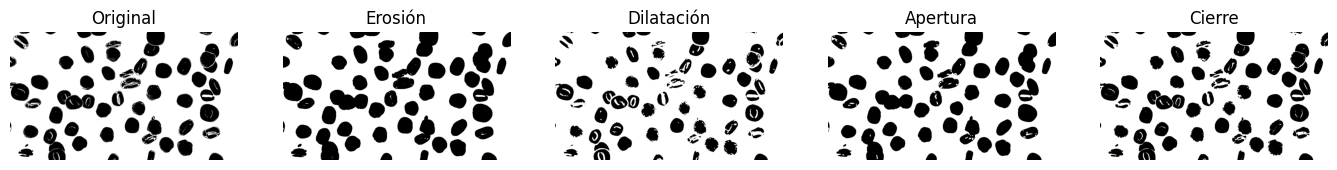

In [ ]:
kernel      = np.ones((5,5), np.uint8)
erosion     = cv2.erode(binary_img, kernel, iterations=1)
dilatacion  = cv2.dilate(binary_img, kernel, iterations=1)
apertura    = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
cierre      = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel)

imagenes    = [binary_img, erosion, dilatacion, apertura, cierre]
titulos     = ['Original', 'Erosión', 'Dilatación', 'Apertura', 'Cierre']

plt.figure(figsize=(17, 11))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(imagenes[i], cmap='gray')
    plt.title(titulos[i])
    plt.axis('off')

plt.show()
